# **Project 1: Working with CIFAR-10**

The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images.

*   Visualize the images in CIFAR-10 dataset. Create a 10 x 10 plot showing 10 random samples from each class.
*   Convert the labels to one-hot encoded form.
*   Normalize the images.

# 1. Data Processing

In [1]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, precision_recall_fscore_support
from IPython.display import display

# Load the raw CIFAR-10 dataset

In [12]:
# This return two tuple containing NumPy arrays
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalization (Feature Scaling)

In [3]:
# Convert pixel values from [0, 255] to [0, 1] for numerical stability
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Preparing Labels: One-Hot Encoding

In [4]:
# Convert class vectors (integers) to binary class matrices
# Necessary for the Categorical Crossentropy loss function

num_classes = 10
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

# 2. Model Architecture: 
 - Design a CNN architecture suitable for image classification.

In [5]:
# Designing a CNN architecture

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Dropout, Flatten

model = Sequential()

# Stack two convolutional layers with 32 Filters (3x3) and same Padding
# Use a max pooling layer and Dropout 
model.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32, 32, 3)))
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.2))

model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.3))


# Flatten the output
model.add(Flatten())

# Add a Dense layer with 128 units
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Classification layer (10 classes of CIFAR-10)
model.add(Dense(10, activation='softmax'))

model.summary()

/opt/anaconda3/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 273,706 (1.04 MB)

 Trainable params: 273,706 (1.04 MB)

 Non-trainable params: 0 (0.00 B)

# 3. Model Training

In [6]:
# Define Early Stopping callback
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

def opt_techniques(optim):
  model.compile(loss='categorical_crossentropy', optimizer=optim, metrics=['accuracy'])

# Compile the Model, optimizer: stochastic gradient descent 'sgd' or 'adam'
opt_techniques(optim='adam')

In [7]:
# Training Model
BATCH_SIZE = 128
history = model.fit(x_train, y_train, epochs=25, batch_size=BATCH_SIZE)

Epoch 1/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.3344 - loss: 1.8136
Epoch 2/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - accuracy: 0.4589 - loss: 1.4896
Epoch 3/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.5052 - loss: 1.3731
Epoch 4/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.5347 - loss: 1.2993
Epoch 5/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.5566 - loss: 1.2370
Epoch 6/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.5775 - loss: 1.1827
Epoch 7/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step - accuracy: 0.5897 - loss: 1.1514
Epoch 8/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.6018 - loss: 1.1215
Epoch 9/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.6108 - loss: 1.0944
Epoch 10/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.6186 - loss: 1.0762
Epoch 11/25
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.6316 - loss: 1.0478
Epoch 12/25
391/391 ━━━━━━━━━━━━━━

# 4. Model Evaluation

Test loss: 0.8134 | Test accuracy: 0.7180
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Classification Report:
              precision    recall  f1-score   support

    airplane       0.75      0.79      0.77      1000
  automobile       0.88      0.76      0.82      1000
        bird       0.71      0.50      0.59      1000
         cat       0.54      0.47      0.51      1000
        deer       0.59      0.74      0.66      1000
         dog       0.62      0.65      0.63      1000
        frog       0.75      0.81      0.78      1000
       horse       0.74      0.81      0.78      1000
        ship       0.87      0.81      0.83      1000
       truck       0.76      0.85      0.81      1000

    accuracy                           0.72     10000
   macro avg       0.72      0.72      0.72     10000
weighted avg       0.72      0.72      0.72     10000



,class,precision,recall,f1
0,airplane,0.748811,0.787,0.767431
1,automobile,0.884615,0.759,0.817008
2,bird,0.705219,0.500,0.585138
3,cat,0.542955,0.474,0.506140
4,deer,0.589457,0.738,0.655417
5,dog,0.616920,0.649,0.632554
6,frog,0.752336,0.805,0.777778
7,horse,0.744250,0.809,0.775276
8,ship,0.866523,0.805,0.834629
9,truck,0.763181,0.854,0.806041


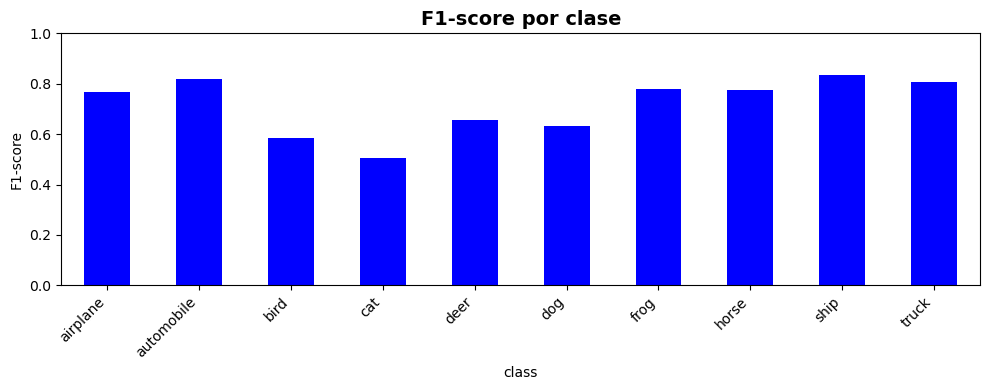

In [8]:
# Complete model evaluation: loss/accuracy, classification report, and metrics 

classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

# Evaluate in the test set
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f'Test loss: {test_loss:.4f} | Test accuracy: {test_acc:.4f}')

# True predictions and labels
y_true = np.argmax(y_test, axis=1)
probs = model.predict(x_test)
y_pred = np.argmax(probs, axis=1)

# Class Report
print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=classes))

# Metrics by class (precision, recall, f1)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=None)
df_metrics = pd.DataFrame({'class': classes, 'precision': precision, 'recall': recall, 'f1': f1})
display(df_metrics)

# F1 plot by class
plt.figure(figsize=(10,4))
df_metrics.set_index('class')['f1'].plot(kind='bar', ylim=(0,1), color='blue')
plt.title('F1-score por clase', fontsize=14, fontweight='bold')
plt.ylabel('F1-score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

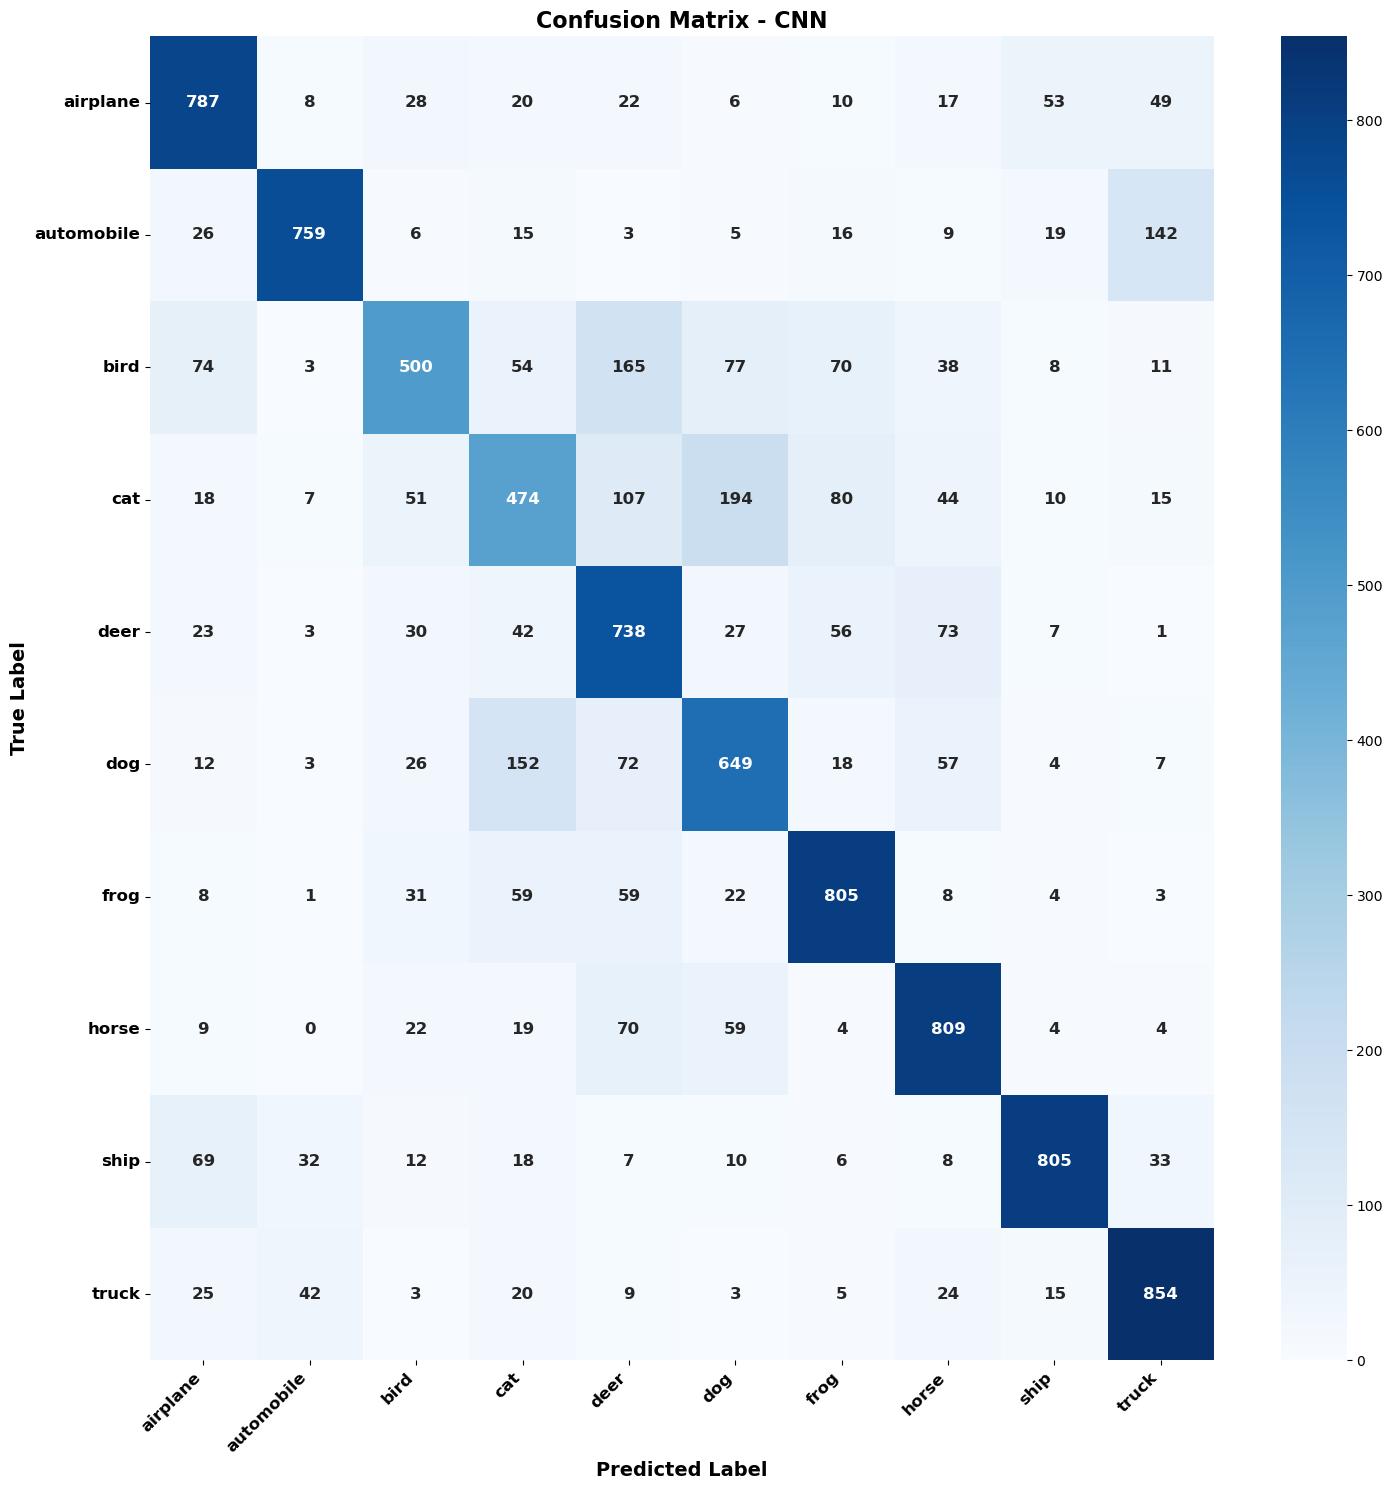

In [9]:
# Confusion Matrix (restaurada): etiquetas con nombre, fuente más grande y negrita
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

# Use existing y_true and y_pred computed in the previous evaluation cell
cm = confusion_matrix(y_true, y_pred)

# Use class names defined earlier
labels = classes

plt.figure(figsize=(15, 15))
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, annot_kws={"size":12, "weight":"bold"})
ax.set_title('Confusion Matrix - CNN', fontsize=16, fontweight='bold')
ax.set_ylabel('True Label', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=12, fontweight='bold')
plt.yticks(rotation=0, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# 5. Transfer Learning
- Evaluate the accuracy of your model on a pre-trained models like ImagNet, VGG16, Inception... (pick one an justify your choice)
- Perform transfer learning with your chosen pre-trained models i.e., you will probably try a few and choose the best one.

In [10]:
import numpy as np
import time

import PIL.Image as Image
import matplotlib.pylab as plt

import tensorflow as tf
import tensorflow_hub as hub

import datetime

%load_ext tensorboard

ModuleNotFoundError: No module named 'tensorflow_hub'